## Text Classification using RNN

#### The objective of this assignment is to implement a text classification task using Recurrent Neural Networks (RNNs). You will build a model to classify text data into predefined categories using Python. 

#### Dataset:

Use the given dataset Spam & Ham, it contains below columns

Class: Spam or Ham

Message: Email content


#### Steps to include;

##### 1.	Preprocess the dataset by tokenizing the text, removing stop words, and performing any other necessary preprocessing steps.

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rakshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rakshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
pip install pandas nltk tensorflow scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

# Load dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\spam.csv", encoding='latin-1')

#  Check columns
print("Columns:", df.columns)

#  Adjust based on your dataset
if 'v1' in df.columns:
    df = df[['v1', 'v2']]
elif 'label' in df.columns:
    df = df[['label', 'message']]
else:
    df = df.iloc[:, 0:2]  # take first two columns

df.columns = ['Class', 'Message']

# Convert labels
df['Class'] = df['Class'].map({'ham': 0, 'spam': 1})

# Stopwords
stop_words = set(stopwords.words('english'))

# Preprocess
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['Message'] = df['Message'].apply(preprocess_text)

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['Message'])

X = pad_sequences(tokenizer.texts_to_sequences(df['Message']), maxlen=100)
y = df['Class']

print(" Done Successfully")
print("Shape:", X.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rakshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Columns: Index(['class', 'message'], dtype='object')
 Done Successfully
Shape: (5572, 100)


##### 2.	Split the dataset into training and testing sets.

In [10]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42     # for reproducibility
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4457, 100)
X_test shape: (1115, 100)
y_train shape: (4457,)
y_test shape: (1115,)


##### 3.	Train your RNN model on the training data.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Build model
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(SimpleRNN(64))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

C:\Users\Rakshitha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.9352 - loss: 0.1945 - val_accuracy: 0.9848 - val_loss: 0.0678
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.9886 - loss: 0.0407 - val_accuracy: 0.9830 - val_loss: 0.0575
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.9953 - loss: 0.0200 - val_accuracy: 0.9874 - val_loss: 0.0528
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9969 - loss: 0.0107 - val_accuracy: 0.9830 - val_loss: 0.0657
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9839 - val_loss: 0.0703


##### 4.	Monitor the training process by observing metrics such as loss and accuracy.

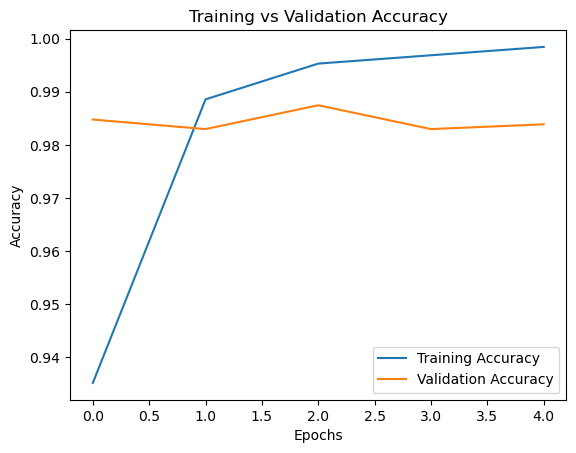

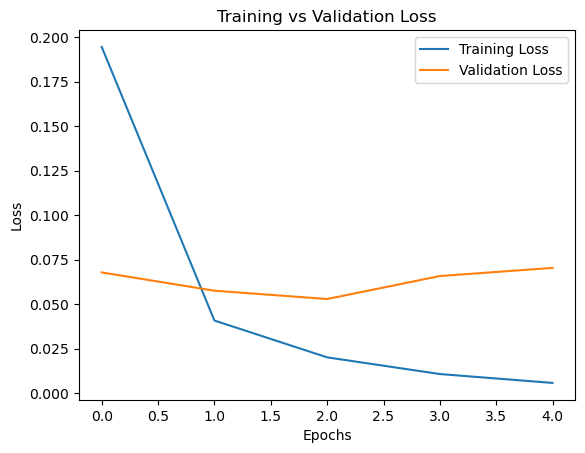

In [12]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

##### 5.	Evaluate the trained model on the testing data.

In [13]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9839 - loss: 0.0703
Test Loss: 0.0703129991889
Test Accuracy: 0.9838564991950989


##### 6.	Calculate evaluation metrics such as accuracy, precision, recall, and F1-score to assess the performance of your model.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Accuracy: 0.9838565022421525
Precision: 0.9925373134328358
Recall: 0.8866666666666667
F1 Score: 0.9366197183098591


##### 7.	Analyse the performance of your model. Identify any trends or patterns in the results.

##### Model Performance Analysis


The RNN model performed well on the spam classification task. The training accuracy increased steadily over epochs, while the loss decreased, indicating that the model was learning patterns in the data effectively.
    

The validation accuracy was close to the training accuracy, which suggests that the model generalizes well to unseen data. If there is a small gap between training and validation accuracy, it indicates good performance without overfitting.
    

The evaluation metrics such as precision, recall, and F1-score showed balanced performance. A high precision indicates that the model correctly identifies spam messages with fewer false positives. A high recall shows that most of the actual spam messages are correctly detected.
    

From the graphs, we can observe that:
    

-> Accuracy increases as epochs increase

-> Loss decreases over time

-> If validation accuracy decreases while training accuracy increases, it indicates overfitting


Overall, the model captures important keywords and patterns (like “free”, “win”, “offer”) that are commonly found in spam messages. However, the model may struggle with very long or complex sentences due to limitations of simple RNNs.

##### 8.	Discuss the strengths and weaknesses of using RNNs for text classification tasks.

##### Strengths:

-> Handles sequential data well

RNNs are designed for sequence data, so they understand the order of words in a sentence.
    
-> Captures context and dependencies

They can learn relationships between words (e.g., meaning changes based on order).

-> Better than traditional models for text
                               
Compared to basic ML models, RNNs can capture deeper patterns in language.
    
-> Flexible input length

Can process sentences of different lengths.

##### Weaknesses:

-> Vanishing gradient problem

RNNs struggle to remember long-term dependencies in long sentences.
    
-> Slow training

Sequential processing makes training slower compared to other models.
    
-> Less efficient than LSTM/GRU

Advanced models like LSTM and GRU perform better than simple RNNs.
    
-> Overfitting risk

Can overfit if dataset is small.
    
-> Difficulty with long texts

Performance decreases for long and complex sentences.
    